# Bell State Generator

Quantum Circuit


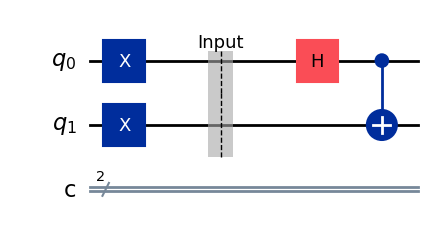

Statevector


<IPython.core.display.Latex object>

Density Matrix


<IPython.core.display.Latex object>

Bloch Sphere


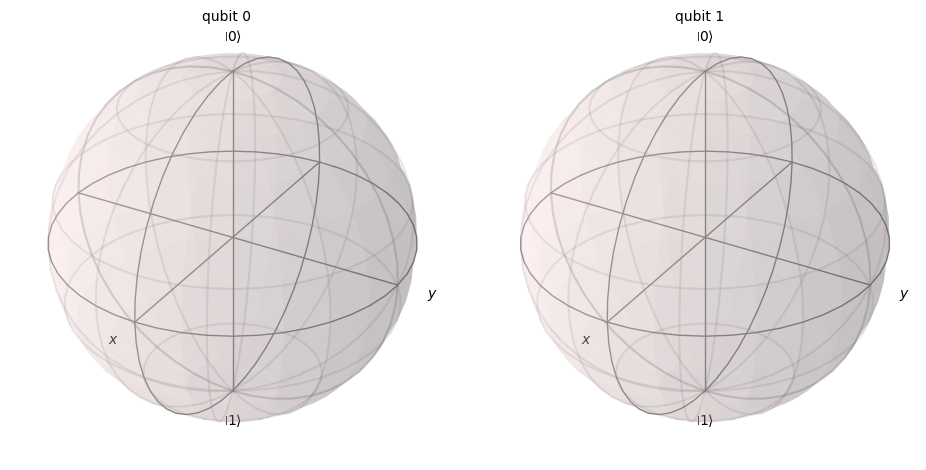

QSphere


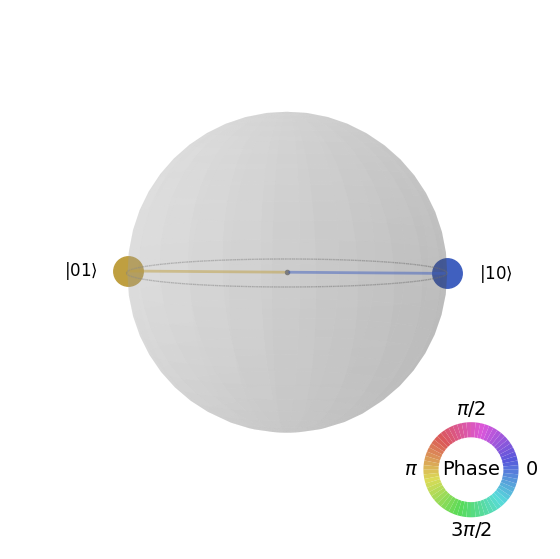

Unitary Operator


array([[ 0.        +0.j,  0.        +0.j,  0.70710678+0.j,
         0.70710678+0.j],
       [-0.70710678+0.j,  0.70710678+0.j,  0.        +0.j,
         0.        +0.j],
       [ 0.70710678+0.j,  0.70710678+0.j,  0.        +0.j,
         0.        +0.j],
       [ 0.        +0.j,  0.        +0.j, -0.70710678+0.j,
         0.70710678+0.j]])

Sampler Counts (1024 shots)
{'01': 500, '10': 524}

Aer Simulator Counts
{'01': 521, '10': 503}
Measurement Histogram


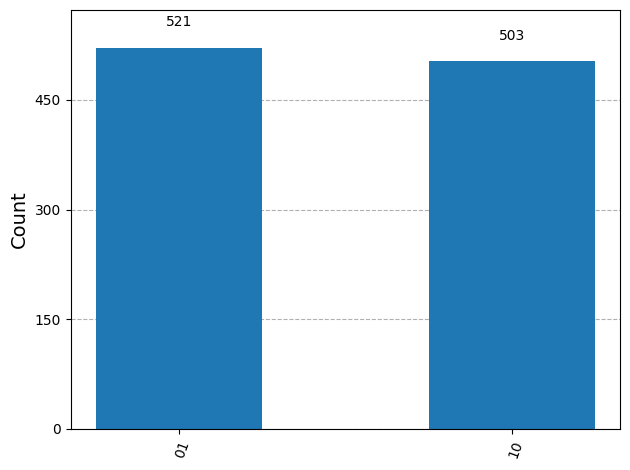

In [70]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, DensityMatrix, Operator
from qiskit.visualization import (
    plot_histogram,
    plot_bloch_multivector,
    plot_state_qsphere
)
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler
from IPython.display import display


# ------------------------------------------------------------------
# Bell State Generator
# ------------------------------------------------------------------
def build_bell_circuit(bell_type="Phi+"):
    qc = QuantumCircuit(2, 2, name=f"Bell_{bell_type}")

    # Prepare input state
    if bell_type in ["Psi+", "Psi-"]:
        qc.x(1)

    if bell_type in ["Phi-", "Psi-"]:
        qc.x(0)

    qc.barrier(label="Input")

    # Bell State Generator
    qc.h(0)
    qc.cx(0, 1)

    return qc


# ------------------------------------------------------------------
# Select Bell State
# Options:
# "Phi+"
# "Phi-"
# "Psi+"
# "Psi-"
# ------------------------------------------------------------------
qc = build_bell_circuit("Psi-")


# ==============================================================
# 1. Circuit Diagram
# ==============================================================
print("Quantum Circuit")
display(qc.draw("mpl"))


# ==============================================================
# 2. Statevector
# ==============================================================
state = Statevector.from_instruction(qc)

print("Statevector")
display(state.draw("latex"))


# ==============================================================
# 3. Density Matrix
# ==============================================================
density = DensityMatrix(state)

print("Density Matrix")
display(density.draw("latex"))


# ==============================================================
# 4. Bloch Sphere
# ==============================================================
print("Bloch Sphere")
display(plot_bloch_multivector(state))


# ==============================================================
# 5. QSphere
# ==============================================================
print("QSphere")
display(plot_state_qsphere(state))


# ==============================================================
# 6. Unitary Operator
# ==============================================================
print("Unitary Operator")
display(Operator(qc).data)


# ==============================================================
# 7. Add Measurements
# ==============================================================
qc_measure = qc.copy()
qc_measure.measure([0, 1], [0, 1])


# ==============================================================
# 8. Sampler
# ==============================================================
sampler = StatevectorSampler()
job = sampler.run([qc_measure], shots=1024)
sampler_result = job.result()

# Extract counts
bitstrings = sampler_result[0].data.c.get_counts()

print("Sampler Counts (1024 shots)")
print(bitstrings)


# ==============================================================
# 9. Aer Simulator Counts
# ==============================================================
simulator = AerSimulator()

result = simulator.run(qc_measure, shots=1024).result()

counts = result.get_counts()

print("\nAer Simulator Counts")
print(counts)


# ==============================================================
# 10. Histogram
# ==============================================================
print("Measurement Histogram")
display(plot_histogram(counts))